In [104]:
import numpy as np
import pandas as pd

np.random.seed(99)
n = 1000
kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga", "Olahraga"]
kota_list = ["Magelang", "Yogyakarta", "Semarang", "Solo", "Purworejo", "Kebumen"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-09-01", "2026-09-30", freq="D")

data = {
    "order_id": [f"ORD-{3000 + i}" for i in range(n)],
    "tanggal": np.random.choice(tanggal_range, size=n).astype(str),
    "kategori": np.random.choice(kategori_list, size=n),
    "kota": np.random.choice(kota_list, size=n),
    "unit_terjual": np.random.randint(1, 12, size=n),
    "harga_satuan": np.random.choice([20000, 45000, 60000, 90000, 125000, 200000, 350000], size=n),
    "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    "rating": np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.03, 0.02, 0.10, 0.30, 0.35, 0.20]),
}
df_tugas4 = pd.DataFrame(data)
df_tugas4.to_csv("transaksi_september_2026.csv", index=False)
print(f"Dataset dibuat: {df_tugas4.shape[0]} baris")

# Mengunggah ke HDFS
!hdfs dfs -mkdir -p /home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4
!hdfs dfs -put -f transaksi_september_2026.csv /home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4
print("Berhasil diunggah ke HDFS: /home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4")

Dataset dibuat: 1000 baris
Berhasil diunggah ke HDFS: /home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4


A. Membaca dan Eksplorasi Awal (bobot 15%)

Baca dataset dari HDFS, tampilkan printSchema(), jumlah baris (count()), dan 10 baris pertama (show(10)).

In [54]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Read HDFS") \
    .getOrCreate()

hdfs_path = "hdfs://localhost:9000/home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4/transaksi_september_2026.csv"

df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

df.printSchema()

jumlah_baris = df.count()
print(f"Total baris: {jumlah_baris}")

df.show(10)

root
 |-- order_id: string (nullable = true)
 |-- tanggal: timestamp (nullable = true)
 |-- kategori: string (nullable = true)
 |-- kota: string (nullable = true)
 |-- unit_terjual: integer (nullable = true)
 |-- harga_satuan: integer (nullable = true)
 |-- metode_pembayaran: string (nullable = true)
 |-- rating: double (nullable = true)

Total baris: 1000
+--------+-------------------+--------------------+----------+------------+------------+-----------------+------+
|order_id|            tanggal|            kategori|      kota|unit_terjual|harga_satuan|metode_pembayaran|rating|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+------+
|ORD-3000|2026-09-02 00:00:00|        Rumah Tangga|Yogyakarta|           3|       90000|              COD|   4.0|
|ORD-3001|2026-09-04 00:00:00|   Makanan & Minuman|      Solo|           3|      200000|         E-Wallet|   5.0|
|ORD-3002|2026-09-26 00:00:00|Kesehatan & Kecan...|  Semarang|         

B. Menangani Data Kosong (bobot 15%)

Kolom rating memiliki nilai kosong. Tampilkan berapa banyak, lalu gunakan df.na.fill() atau df.na.drop() (pilih salah satu, jelaskan alasannya pada markdown cell) untuk menanganinya.

In [125]:
from pyspark.sql.functions import col
hdfs_path = "hdfs://localhost:9000/home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4/transaksi_september_2026.csv"

df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

tampilkan_rating = df.filter(col("rating").isNull()) \
    .count()
print("total nilai kosong: ", tampilkan_rating)

tambah = df.na.fill(4.0, subset=["rating"])

tambah.show()

total nilai kosong:  204
+--------+-------------------+--------------------+----------+------------+------------+-----------------+------+
|order_id|            tanggal|            kategori|      kota|unit_terjual|harga_satuan|metode_pembayaran|rating|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+------+
|ORD-3000|2026-09-02 00:00:00|        Rumah Tangga|Yogyakarta|           3|       90000|              COD|   4.0|
|ORD-3001|2026-09-04 00:00:00|   Makanan & Minuman|      Solo|           3|      200000|         E-Wallet|   5.0|
|ORD-3002|2026-09-26 00:00:00|Kesehatan & Kecan...|  Semarang|           8|       60000|         E-Wallet|   3.0|
|ORD-3003|2026-09-09 00:00:00|   Makanan & Minuman|  Semarang|           6|      350000|    Transfer Bank|   4.0|
|ORD-3004|2026-09-10 00:00:00|        Rumah Tangga|Yogyakarta|          10|       60000|         E-Wallet|   4.0|
|ORD-3005|2026-09-09 00:00:00|             Fashion| Purworejo| 

Jawaban B:
Karena kolom tersebut masih kosong maka umumnya perlu diisi terlebih dahulu menggunakan df.na.fill() sebelum menghapus isinya

C. Transformasi Data (bobot 20%)

Tambahkan kolom total_pendapatan (unit_terjual x harga_satuan), lalu tambahkan kolom tier_transaksi yang bernilai "Besar" jika total_pendapatan > 500000, atau "Kecil" jika sebaliknya

In [129]:
from pyspark.sql.functions import sum as spark_sum, count, avg

hdfs_path = "hdfs://localhost:9000/home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4/transaksi_september_2026.csv"

df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

df = df.withColumn("total_pendapatan", col("unit_terjual") * col("harga_satuan"))

df = df.withColumn("tier_besar", col("total_pendapatan") > 500000)
df = df.withColumn("tier_kecil", col("total_pendapatan") < 500000)

hanya = df.select("total_pendapatan", "tier_besar", "tier_kecil")
hanya.show()

+----------------+----------+----------+
|total_pendapatan|tier_besar|tier_kecil|
+----------------+----------+----------+
|          270000|     false|      true|
|          600000|      true|     false|
|          480000|     false|      true|
|         2100000|      true|     false|
|          600000|      true|     false|
|          100000|     false|      true|
|           40000|     false|      true|
|          720000|      true|     false|
|          140000|     false|      true|
|          900000|      true|     false|
|         1400000|      true|     false|
|          240000|     false|      true|
|         1000000|      true|     false|
|         1600000|      true|     false|
|           60000|     false|      true|
|         1600000|      true|     false|
|          450000|     false|      true|
|         1000000|      true|     false|
|          990000|      true|     false|
|          250000|     false|      true|
+----------------+----------+----------+
only showing top

D. Analisis dengan GroupBy (bobot 30%)

Jawablah dengan kode PySpark (bukan pandas):

Kategori apa yang memiliki total_pendapatan tertinggi?
Kota mana dengan jumlah transaksi tier "Besar" terbanyak?
Berapa rata-rata rating untuk masing-masing metode_pembayaran (data kosong sudah ditangani di bagian B)?


In [127]:
from pyspark.sql.functions import col, count, desc
from pyspark.sql.functions import sum

df = df_pendapatan.withColumn("total_pendapatan", col("unit_terjual") * col("harga_satuan"))

df_kategori_pendapatan_tinggi = df.groupBy("kategori").agg(
    sum("total_pendapatan").alias("total_uang_masuk") \
).orderBy(col("total_uang_masuk").desc())

print("kategori dengan pendapatan tertinggi")
df_kategori_pendapatan_tinggi.show()
# =========================================================================

df_kota_transaksi = df.filter(col("total_pendapatan") > 500000)

df_kota_terbanyak = df_kota_transaksi.groupBy("kota") \
    .agg(count("order_id").alias("transaksi") \
).orderBy(col("transaksi").desc())

print("kota dengan transaksi tier besar")
df_kota_terbanyak.show(1)

# ===========================================================================

rata_rata = df.groupBy("metode_pembayaran").agg(
    avg("rating").alias("rata_rata_rating")
).orderBy(col("rata_rata_rating").desc())

print("rata rata rating masing masing metode pembayaran")
rata_rata.show()

kategori dengan pendapatan tertinggi
+--------------------+----------------+
|            kategori|total_uang_masuk|
+--------------------+----------------+
|        Rumah Tangga|       138665000|
|   Makanan & Minuman|       131890000|
|Kesehatan & Kecan...|       128595000|
|            Olahraga|       126650000|
|             Fashion|       124075000|
|          Elektronik|       110295000|
+--------------------+----------------+

kota dengan transaksi tier besar
+----+---------+
|kota|transaksi|
+----+---------+
|Solo|       92|
+----+---------+
only showing top 1 row

rata rata rating masing masing metode pembayaran
+-----------------+-----------------+
|metode_pembayaran| rata_rata_rating|
+-----------------+-----------------+
|              COD|4.172413793103448|
|    Transfer Bank| 4.16256157635468|
|         E-Wallet|4.135678391959799|
|     Kartu Kredit|4.109947643979058|
+-----------------+-----------------+



E. Menyimpan Hasil ke HDFS (bobot 20%)

Simpan DataFrame hasil olahan bagian C (lengkap dengan kolom total_pendapatan dan tier_transaksi) ke HDFS dalam format CSV baru, kemudian verifikasi apakah sudah berhasil.

In [133]:
df_pandas = hanya.toPandas()

df_pandas.to_csv("data_olahan_bagian_C.csv", index=False)

!hdfs dfs -put data_olahan_bagian_C.csv /home/bungakmal/Documents/praktikum-big_data/Tugas/pertemuan_4

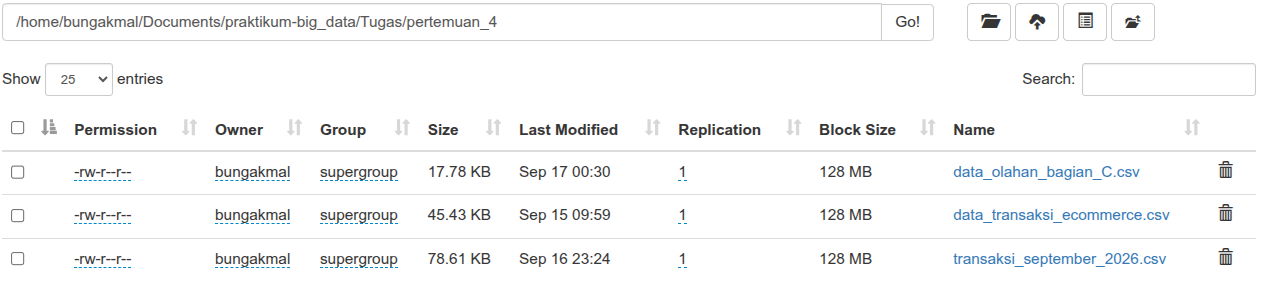

Spark menyimpan hasil sebagai beberapa berkas partisi?
karena alasan efisiensi dan kinerja, Spark didesign untuk memiliki kecepatan, efisiensi, menghindari kesalahan, dan menghindari penurunan kecepatan.